# Experiment 2: MLP for Multi-Class Image Classification (Fashion-MNIST)
CS3807 - Deep Learning Laboratory

## Imports

In [1]:
import sklearn
print(f"Current scikit-learn version: {sklearn.__version__}")

!pip uninstall -y scikit-learn

!pip install "scikit-learn<1.6.0"


Current scikit-learn version: 1.6.1
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 166.3 MB/s eta 0:00:00


In [2]:
!pip install scikeras

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Install tensorflow if it's not present
try:
    import tensorflow
except ImportError:
    !pip install tensorflow

from keras.datasets import fashion_mnist
from tensorflow import keras

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Task 1: Dataset Exploration

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10


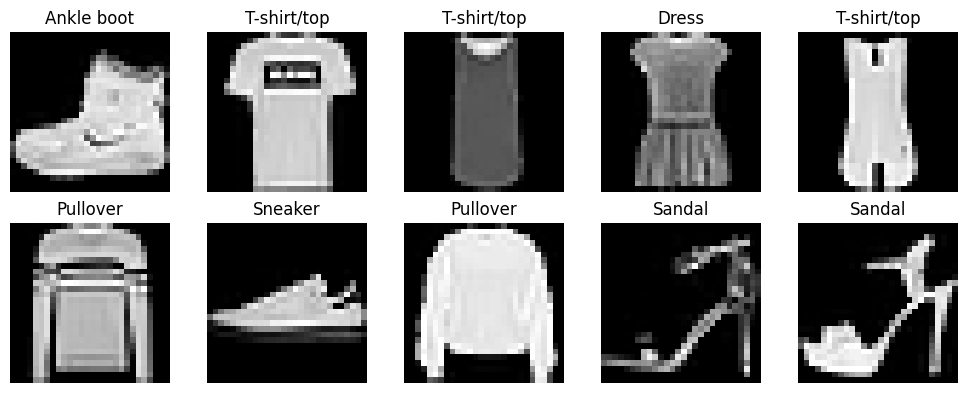

In [3]:
# Display 10 sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

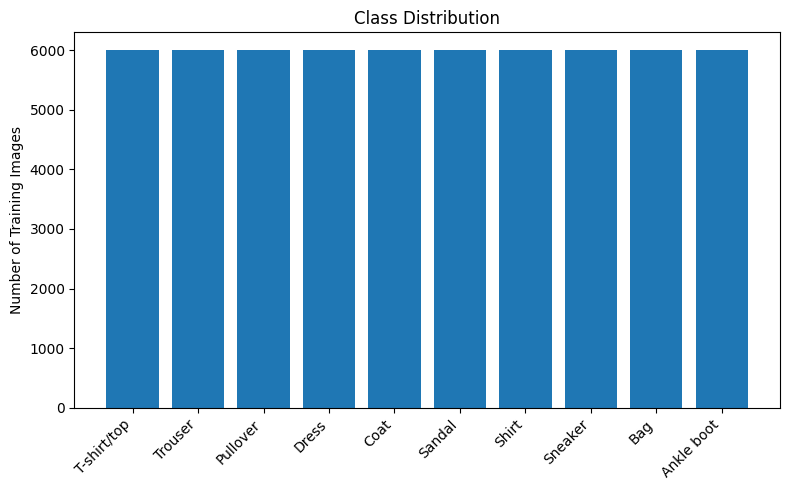

In [4]:
# Plot class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Training Images")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## Task 2: Data Preprocessing

In [5]:
print("Shape before preprocessing:", x_train.shape, x_test.shape)

# Flatten images
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# Normalize pixel values
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("Shape after preprocessing:", x_train_flat.shape, x_test_flat.shape)
print("Shape of one-hot labels:", y_train_oh.shape, y_test_oh.shape)

Shape before preprocessing: (60000, 28, 28) (10000, 28, 28)
Shape after preprocessing: (60000, 784) (10000, 784)
Shape of one-hot labels: (60000, 10) (10000, 10)


## Task 3: Model Construction

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training

In [7]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(x_train_flat, y_train_oh,
                     epochs=20,
                     batch_size=32,
                     validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8215 - loss: 0.5046 - val_accuracy: 0.8573 - val_loss: 0.4037
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8634 - loss: 0.3754 - val_accuracy: 0.8667 - val_loss: 0.3572
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8759 - loss: 0.3359 - val_accuracy: 0.8702 - val_loss: 0.3518
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8836 - loss: 0.3110 - val_accuracy: 0.8788 - val_loss: 0.3414
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8910 - loss: 0.2936 - val_accuracy: 0.8630 - val_loss: 0.3769
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8952 - loss: 0.2802 - val_accuracy: 0.8808 - val_loss: 0.3291
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8991 - loss: 0.2686 - val_accuracy: 0.8773 - val_loss: 0.3487
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9056 - loss: 0.2562 - 

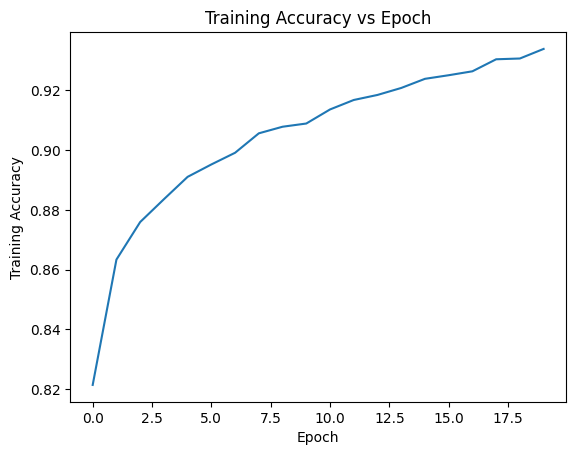

In [8]:
# Training Accuracy vs Epoch
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.show()

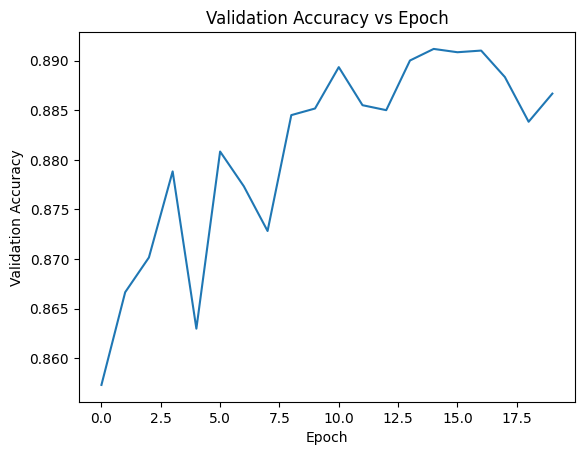

In [9]:
# Validation Accuracy vs Epoch
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.show()

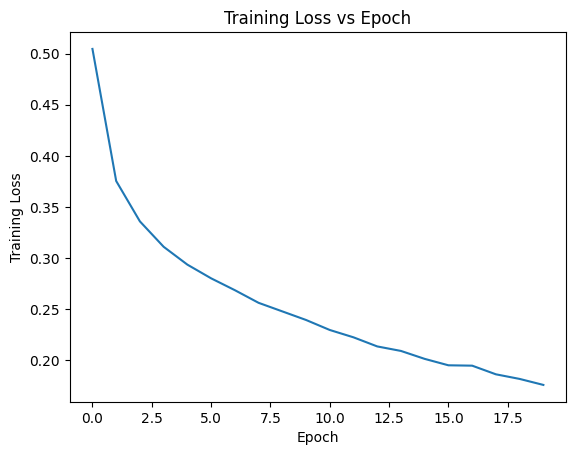

In [10]:
# Training Loss vs Epoch
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.show()

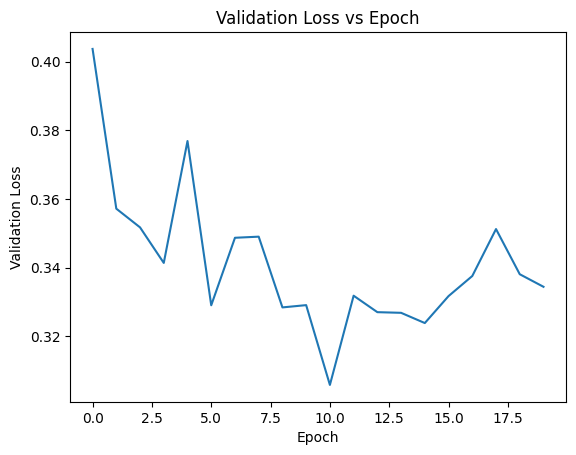

In [11]:
# Validation Loss vs Epoch
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.show()

## Task 5: Model Evaluation

In [12]:
y_pred_prob = model.predict(x_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step
Accuracy: 0.8837
Precision: 0.8853620799253346
Recall: 0.8836999999999999
F1-score: 0.882846565277382


In [13]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.82      0.75      0.78      1000
       Dress       0.88      0.89      0.89      1000
        Coat       0.72      0.89      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.77      0.64      0.70      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



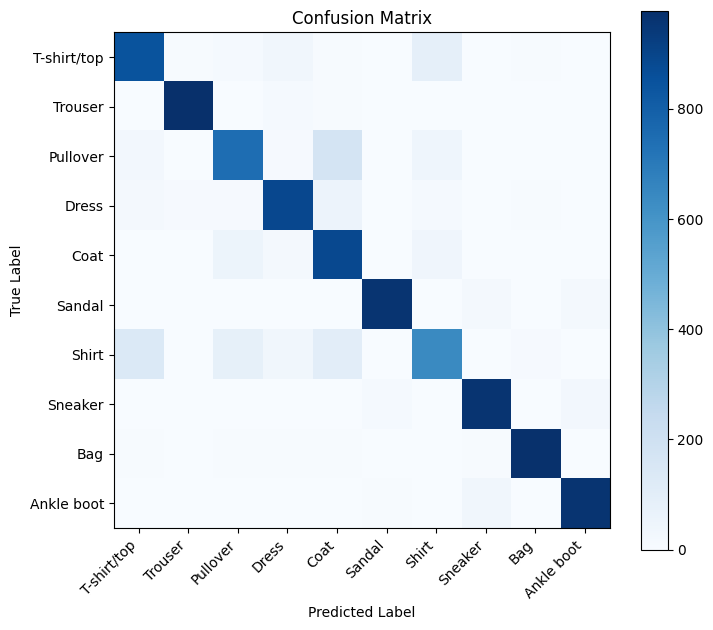

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Hyperparameter Optimization

In [15]:
def build_model(hidden_layers=1, hidden_neurons=64, activation="relu",
                 dropout=0.0, meta=None):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(n_features_in,)))
    for _ in range(hidden_layers):
        model.add(keras.layers.Dense(hidden_neurons, activation=activation))
        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(n_classes, activation="softmax"))
    return model

In [16]:
param_distributions = {
    "hidden_layers": [1, 2, 3],
    "hidden_neurons": [32, 64, 128, 256],
    "optimizer__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "optimizer": ["sgd", "adam", "rmsprop"],
    "activation": ["relu", "tanh", "sigmoid"],
    "dropout": [0.0, 0.2, 0.5],
}

clf = KerasClassifier(
    model=build_model,
    hidden_layers=1,
    hidden_neurons=64,
    activation="relu",
    dropout=0.0,
    optimizer="adam",
    optimizer__learning_rate=0.001,
    loss="categorical_crossentropy",
    epochs=10,
    batch_size=32,
    verbose=0,
)

In [17]:
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    verbose=2,
)

random_search.fit(x_train_flat, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END activation=relu, batch_size=16, dropout=0.0, epochs=20, hidden_layers=1, hidden_neurons=32, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  49.5s
[CV] END activation=relu, batch_size=16, dropout=0.0, epochs=20, hidden_layers=1, hidden_neurons=32, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  49.8s
[CV] END activation=relu, batch_size=16, dropout=0.0, epochs=20, hidden_layers=1, hidden_neurons=32, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  49.3s
[CV] END activation=relu, batch_size=16, dropout=0.0, epochs=20, hidden_layers=1, hidden_neurons=32, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  49.4s
[CV] END activation=relu, batch_size=16, dropout=0.0, epochs=20, hidden_layers=1, hidden_neurons=32, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  48.9s
[CV] END activation=relu, batch_size=32, dropout=0.5, epochs=30, hidden_layers=1, hidden_

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(activation='relu', batch_size=32, dropout=0.0, epochs=10, hidden_layers=1, hidden_neurons=64, loss='categorical_crossentropy', model=<function build_model at 0x7a4d73cc28e0>, optimizer='adam', optimizer__learning_rate=0.001, verbose=0),
                   param_distributions={'activation': ['relu', 'tanh',
                                                       'sigmoid'],
                                        'batch_size': [16, 32, 64, 128],
                                        'dropout': [0.0, 0.2, 0.5],
                                        'epochs': [10, 20, 30],
                                        'hidden_layers': [1, 2, 3],
                                        'hidden_neurons': [32, 64, 128, 256],
                                        'optimizer': ['sgd', 'adam', 'rmsprop'],
                                        'optimizer__learning_rate': [0.1, 0.01,
                                                                     0.001]},
                   verbose=2)

In [18]:
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

Best Parameters: {'optimizer__learning_rate': 0.1, 'optimizer': 'sgd', 'hidden_neurons': 32, 'hidden_layers': 2, 'epochs': 20, 'dropout': 0.2, 'batch_size': 16, 'activation': 'tanh'}
Best Cross-Validation Accuracy: 0.8680833333333334


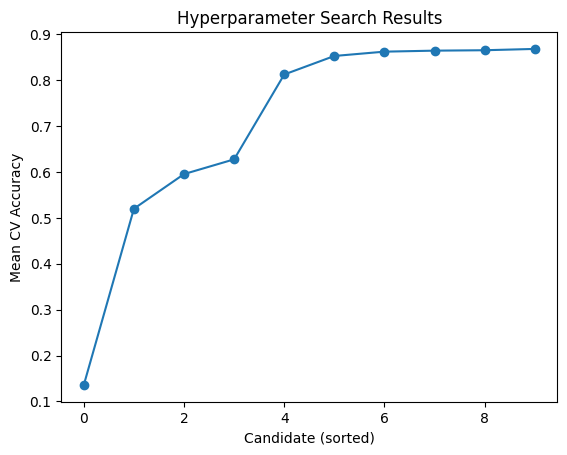

In [19]:
# Hyperparameter Search Results plot
mean_scores = random_search.cv_results_["mean_test_score"]

plt.plot(sorted(mean_scores), marker="o")
plt.xlabel("Candidate (sorted)")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")
plt.show()

## Retrain Optimized Model on Full Training Data

In [20]:
best_params = random_search.best_params_

optimized_model = keras.Sequential()
optimized_model.add(keras.layers.Input(shape=(784,)))
for _ in range(best_params["hidden_layers"]):
    optimized_model.add(keras.layers.Dense(best_params["hidden_neurons"],
                                            activation=best_params["activation"]))
    if best_params["dropout"] > 0:
        optimized_model.add(keras.layers.Dropout(best_params["dropout"]))
optimized_model.add(keras.layers.Dense(10, activation="softmax"))

optimized_model.compile(
    optimizer=keras.optimizers.get({
        "class_name": best_params["optimizer"],
        "config": {"learning_rate": best_params["optimizer__learning_rate"]}
    }),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

optimized_model.summary()

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_166 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_108 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,506 (103.54 KB)

 Trainable params: 26,506 (103.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
opt_history = optimized_model.fit(
    x_train_flat, y_train_oh,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.1
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7761 - loss: 0.6226 - val_accuracy: 0.8362 - val_loss: 0.4589
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 934us/step - accuracy: 0.8220 - loss: 0.5053 - val_accuracy: 0.8420 - val_loss: 0.4454
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 951us/step - accuracy: 0.8310 - loss: 0.4786 - val_accuracy: 0.8490 - val_loss: 0.4272
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 921us/step - accuracy: 0.8403 - loss: 0.4598 - val_accuracy: 0.8588 - val_loss: 0.4037
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 929us/step - accuracy: 0.8438 - loss: 0.4425 - val_accuracy: 0.8563 - val_loss: 0.4046
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 927us/step - accuracy: 0.8479 - loss: 0.4359 - val_accuracy: 0.8610 - val_loss: 0.4034
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 919us/step - accuracy: 0.8499 - loss: 0.4289 - val_accuracy: 0.8448 - val_loss: 0.4119
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 3s 935us/step - accuracy: 0.8529 - l

## Evaluate Optimized Model

In [22]:
y_pred_prob_opt = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_prob_opt, axis=1)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average="macro")
opt_rec = recall_score(y_test, y_pred_opt, average="macro")
opt_f1 = f1_score(y_test, y_pred_opt, average="macro")

print("Optimized Accuracy:", opt_acc)
print("Optimized Precision:", opt_prec)
print("Optimized Recall:", opt_rec)
print("Optimized F1-score:", opt_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step
Optimized Accuracy: 0.8526
Optimized Precision: 0.8630845879180621
Optimized Recall: 0.8526
Optimized F1-score: 0.855546059848816


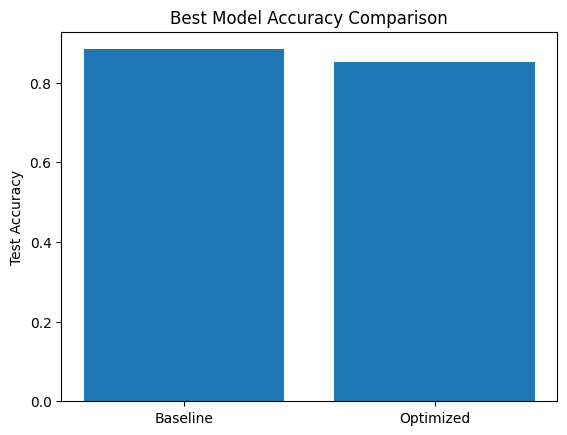

In [23]:
# Best Model Accuracy Comparison
plt.bar(["Baseline", "Optimized"], [acc, opt_acc])
plt.ylabel("Test Accuracy")
plt.title("Best Model Accuracy Comparison")
plt.show()